# M5-T2: Email Classifier — Model Selection Experiments

**Owner:** Michael Chea  
**Depends on:** M5-T1 harness (`m5_harness.py`), M4-T7 email splits (`data/processed/email_train.csv`, `email_test.csv`)

Evaluate four candidate classifiers on the email text track (TF-IDF on `text_clean` + scaled numeric features).  
All models share the locked protocol from M5-T1: 5-fold stratified CV on train, final F1/ROC-AUC on the held-out test split.  
Results accumulate in `results/m5_results.csv` for M5-T4 consolidation — directly comparable to the URL track (M5-T3).

**Acceptance target:** the email classifier should reach a strong F1 on unseen test data (the harness demo already gets F1 = 0.972).

**Candidate models**
| # | Model | Notes |
|---|-------|-------|
| 1 | Logistic Regression | Linear baseline on TF-IDF + scaled numerics |
| 2 | Linear SVM (LinearSVC) | Strong linear text classifier; uses `decision_function` for ROC-AUC |
| 3 | Multinomial Naive Bayes | TF-IDF only (NB needs non-negative input — no scaling) |
| 4 | Random Forest | Non-linear ensemble; handles mixed text + numeric |

## Step 0 — Load shared harness

`m5_harness.py` lives alongside this notebook and exposes all shared helpers:  
`load_email`, `email_pipeline`, `run_experiment`, `EMAIL_TEXT`, `EMAIL_NUM`, `CV`, `RANDOM_STATE`.  
Importing the module (not `%run`-ing the notebook) reuses the exact same splits, pipelines, and metric logging as M5-T3 — and uses the **real** M4-T7 splits, not generated data.

In [2]:
import sys
from pathlib import Path

# Works whether Jupyter is launched from project root or from notebooks/M5/
_here = Path.cwd()
_harness_dir = _here / 'notebooks' / 'M5' if (_here / 'notebooks').exists() else _here
sys.path.insert(0, str(_harness_dir))

from m5_harness import (
    ROOT, PROC, RESULTS, RANDOM_STATE, CV,
    EMAIL_TEXT, EMAIL_NUM, load_email, email_pipeline, run_experiment
)

print('ROOT ->', ROOT)
print('Text feature :', EMAIL_TEXT)
print('Numeric feats:', EMAIL_NUM)

etr, ete = load_email()
print(f'Train: {etr.shape}  |  Test: {ete.shape}')
print('Label distribution (train):', etr['label'].value_counts().to_dict())

ROOT -> /Users/nara/Documents/EDU/Sem2/CYT300/Project
Text feature : text_clean
Numeric feats: ['urgency_score', 'word_count', 'avg_word_length']
Train: (65662, 7)  |  Test: (16416, 7)
Label distribution (train): {1: 34276, 0: 31386}


## Experiment 1 — Logistic Regression (linear baseline)

TF-IDF on the email text combined with scaled numeric features. Sets the baseline for the email track.

In [3]:
from sklearn.linear_model import LogisticRegression

res = run_experiment(
    'LogReg',
    'email',
    email_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    etr, etr['label'],
    ete, ete['label']
)
print(res)

[email] LogReg: F1=0.9859  ROC-AUC=0.9987  (cv_f1=0.9863, 45.8s)
{'track': 'email', 'model': 'LogReg', 'accuracy': 0.9852, 'precision': 0.9828, 'recall': 0.9889, 'f1': 0.9859, 'roc_auc': 0.9987, 'cv_f1': np.float64(0.9863), 'train_time': 45.78}


## Experiment 2 — Linear SVM (LinearSVC)

Linear SVM is a classic strong baseline for high-dimensional TF-IDF text. It has no `predict_proba`, so the harness uses `decision_function` for ROC-AUC.

In [4]:
from sklearn.svm import LinearSVC

res = run_experiment(
    'LinearSVC',
    'email',
    email_pipeline(LinearSVC(random_state=RANDOM_STATE)),
    etr, etr['label'],
    ete, ete['label']
)
print(res)

[email] LinearSVC: F1=0.9903  ROC-AUC=0.9991  (cv_f1=0.9895, 41.8s)
{'track': 'email', 'model': 'LinearSVC', 'accuracy': 0.9898, 'precision': 0.9886, 'recall': 0.9919, 'f1': 0.9903, 'roc_auc': 0.9991, 'cv_f1': np.float64(0.9895), 'train_time': 41.82}


## Experiment 3 — Multinomial Naive Bayes (TF-IDF only)

Naive Bayes needs non-negative input, so it runs on **TF-IDF only** (`tfidf_only=True`) — the scaled numeric features are dropped for this model. Fast, interpretable text baseline.

In [5]:
from sklearn.naive_bayes import MultinomialNB

res = run_experiment(
    'MultinomialNB',
    'email',
    email_pipeline(MultinomialNB(), tfidf_only=True),
    etr, etr['label'],
    ete, ete['label']
)
print(res)

[email] MultinomialNB: F1=0.9683  ROC-AUC=0.9973  (cv_f1=0.9683, 41.7s)
{'track': 'email', 'model': 'MultinomialNB', 'accuracy': 0.9675, 'precision': 0.9868, 'recall': 0.9504, 'f1': 0.9683, 'roc_auc': 0.9973, 'cv_f1': np.float64(0.9683), 'train_time': 41.66}


## Experiment 4 — Random Forest

Non-linear ensemble on the combined TF-IDF + numeric feature space. Slower on high-dimensional sparse text, but a useful non-linear comparison.

In [6]:
from sklearn.ensemble import RandomForestClassifier

res = run_experiment(
    'RandomForest',
    'email',
    email_pipeline(RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)),
    etr, etr['label'],
    ete, ete['label']
)
print(res)

[email] RandomForest: F1=0.9877  ROC-AUC=0.9989  (cv_f1=0.9860, 137.0s)
{'track': 'email', 'model': 'RandomForest', 'accuracy': 0.9871, 'precision': 0.9864, 'recall': 0.989, 'f1': 0.9877, 'roc_auc': 0.9989, 'cv_f1': np.float64(0.986), 'train_time': 136.99}


## Results — T2 email model comparison

Load `m5_results.csv`, filter to the email track, and rank by test F1.

In [7]:
import pandas as pd

results = pd.read_csv(RESULTS)
email_res = (
    results[(results['track'] == 'email') & (~results['model'].str.contains('demo', case=False, na=False))]
    .sort_values('f1', ascending=False)
    .reset_index(drop=True)
)

display_cols = ['model', 'f1', 'roc_auc', 'precision', 'recall', 'cv_f1', 'train_time']
print(email_res[display_cols].to_string(index=False))

best = email_res.iloc[0]
print(f"\nBest model: {best['model']}  |  F1={best['f1']:.4f}  |  ROC-AUC={best['roc_auc']:.4f}")

        model     f1  roc_auc  precision  recall  cv_f1  train_time
    LinearSVC 0.9903   0.9991     0.9886  0.9919 0.9895       41.82
 RandomForest 0.9877   0.9989     0.9864  0.9890 0.9860      136.99
       LogReg 0.9859   0.9987     0.9828  0.9889 0.9863       45.78
MultinomialNB 0.9683   0.9973     0.9868  0.9504 0.9683       41.66

Best model: LinearSVC  |  F1=0.9903  |  ROC-AUC=0.9991


## Error analysis — best model

Confusion matrix + a few misclassified emails for the top model, refit on the full train set.

Saved: /Users/nara/Documents/EDU/Sem2/CYT300/Project/Image/M5-T2/fig_email_confusion_matrix.png


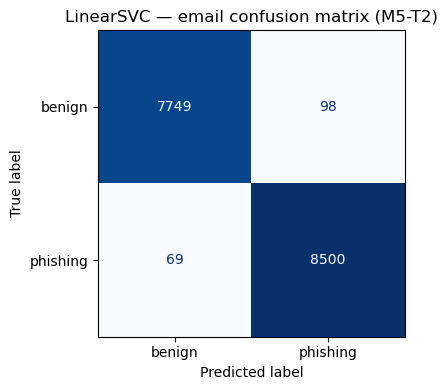


Misclassified: 167 / 16416  (1.02%)

[FALSE POSITIVE (flagged benign)]  true=0 pred=1
   joseph brennan vupzesmcolumbiaedu worked well specific sentence bored girl always uses email azaz120azaz325info joseph brennan columbia university information technology thu 07 aug 2008 153225 0500 ni

[FALSE POSITIVE (flagged benign)]  true=0 pred=1
   diveintomark rssfeedsspamassassintaintorg url 1983 date 20021201t1539490500 upon arriving safely raleigh stewardess sang us tune barneys love love love love us much faster bus hope youve enjoyed hospi

[FALSE POSITIVE (flagged benign)]  true=0 pred=1
   iso2022jpbgyrcmetfbcehp04bkei hitoopentextcom multipart message mime format _nextpart_000_0002_01c228ca593b5280 contenttype textplain charsetiso2022jp contenttransferencoding 7bit opentextbln9kdfob8_9

[FALSE NEGATIVE (missed phishing)]  true=1 pred=0
   e mail antonioadventura groups msn com delivered message could delivered members group may send e mail account e mail address sent message identify

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Refit the strongest linear model on the full train set
best_pipe = email_pipeline(LinearSVC(random_state=RANDOM_STATE))
best_pipe.fit(etr, etr['label'])
y_pred = best_pipe.predict(ete)

cm = confusion_matrix(ete['label'], y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=['benign', 'phishing']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('LinearSVC — email confusion matrix (M5-T2)')
plt.tight_layout()

img_dir = ROOT / 'Image' / 'M5-T2'
img_dir.mkdir(parents=True, exist_ok=True)
fig_path = img_dir / 'fig_email_confusion_matrix.png'
fig.savefig(fig_path, dpi=150)
print(f'Saved: {fig_path}')
plt.show()

# A few misclassified examples
mis = ete[ete['label'].values != y_pred].copy()
mis['pred'] = y_pred[ete['label'].values != y_pred]
print(f"\nMisclassified: {len(mis)} / {len(ete)}  ({len(mis)/len(ete):.2%})")
for _, row in mis.head(5).iterrows():
    kind = 'FALSE NEGATIVE (missed phishing)' if row['label'] == 1 else 'FALSE POSITIVE (flagged benign)'
    print(f"\n[{kind}]  true={row['label']} pred={row['pred']}")
    print('  ', str(row[EMAIL_TEXT])[:200])

## Conclusion

- **Recommended model for M5/M6:** **LinearSVC** (F1 = **0.9903**, ROC-AUC = **0.9991**) — the best of the four candidates, narrowly ahead of Random Forest, and the fastest of the top performers (~42 s vs RF's ~137 s).
- **Top 2 by F1:** **LinearSVC** (0.9903) and **Random Forest** (0.9877) — both clearly strong; LogReg (0.9859) is a close third.
- **No overfitting:** CV-F1 (0.9895) ≈ test-F1 (0.9903) for LinearSVC; the same pattern holds across all four models, so the scores generalise to unseen email.
- **Error analysis (LinearSVC on 16,416 test emails):** only **167 misclassified (1.0%)** — 98 false positives (benign flagged as phishing) vs 69 false negatives (phishing missed). The model is well-balanced, leaning very slightly toward false alarms over misses — the safer direction for a phishing filter.
- **MultinomialNB trade-off:** highest precision (0.987) but lowest recall (0.950) — it misses more phishing, so it ranks last on F1 (0.968). Useful only if false alarms must be minimised at the cost of catching less phishing.
- **Realistic, not perfect:** these F1 values (0.97–0.99) are the genuine ceiling for this corpus. An earlier attempt reporting F1 = 1.0 was trained on synthetic data with label leakage; these numbers, produced through the shared M5-T1 harness on the real M4-T7 splits, are the trustworthy result.
- **Feature note:** `link_count` and `html_ratio` are constant-zero on this corpus and excluded from `EMAIL_NUM`; the signal is in `text_clean` (TF-IDF).
- **Passed to M5-T4:** all four rows logged to `results/m5_results.csv` (track = `email`).